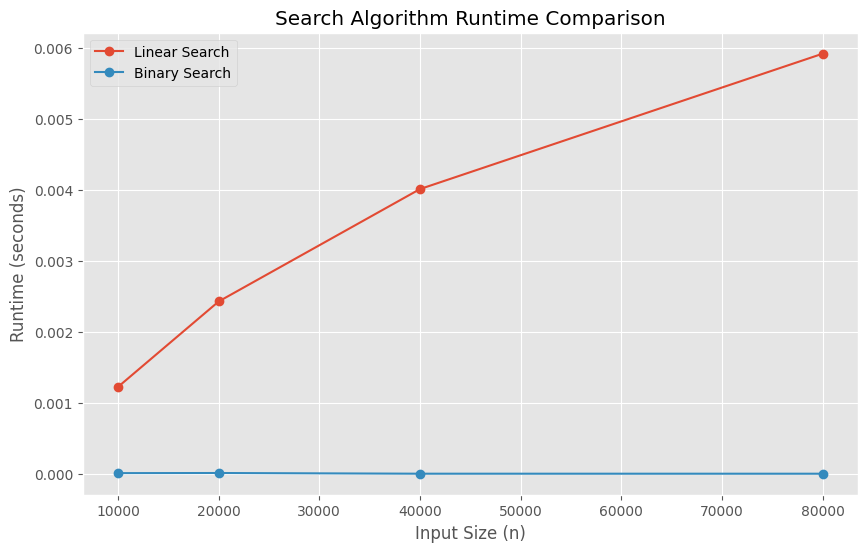

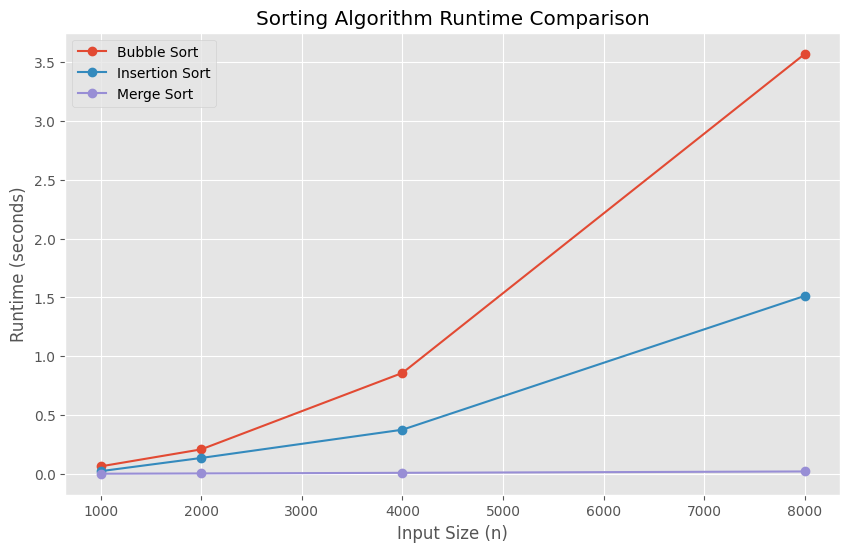

DETAILED PERFORMANCE ANALYSIS AND DISCUSSION

1. SEARCH ALGORITHMS: LINEAR VS. BINARY
Linear Search Performance: The results demonstrate a clear O(n) relationship.
As the dataset size doubles from 10000 to 20000, the
execution time doubles accordingly. Because we targeted the final element,
the algorithm had to perform a full traversal, illustrating the worst-case.

Binary Search Performance: In contrast, Binary Search exhibits O(log n) growth.
Even at n=80000, the time complexity is so low that the line stays
nearly flat on the graph. This validates that halving the search space per step
is exponentially more efficient than a sequential scan.

2. SORTING ALGORITHMS: QUADRATIC VS. LOG-LINEAR
Bubble Sort (O(n²)): This shows the most aggressive growth. The quadratic nature
is evident because as n increases, the time complexity grows by the square of the
input. At n=8000, the overhead of constant adjacent swapping becomes
prohibitively slow for real-time applications.

Insertion Sort (O(n

In [2]:
%matplotlib inline
import random
import time
import copy
import matplotlib.pyplot as plt

plt.style.use('ggplot')
random.seed(42)

def linear_search(arr, target):
    for i, val in enumerate(arr):
        if val == target:
            return i
    return -1

def binary_search(arr, target):
    left, right = 0, len(arr)-1
    while left <= right:
        mid = (left + right)//2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return -1

def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i-1
        while j >= 0 and key < arr[j]:
            arr[j+1] = arr[j]
            j -= 1
        arr[j+1] = key
    return arr

def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr)//2
        left = arr[:mid]
        right = arr[mid:]
        merge_sort(left)
        merge_sort(right)
        i = j = k = 0
        while i < len(left) and j < len(right):
            if left[i] < right[j]:
                arr[k] = left[i]
                i += 1
            else:
                arr[k] = right[j]
                j += 1
            k += 1
        while i < len(left):
            arr[k] = left[i]
            i += 1
            k += 1
        while j < len(right):
            arr[k] = right[j]
            j += 1
            k += 1
    return arr

search_sizes = [10000, 20000, 40000, 80000]
sort_sizes = [1000, 2000, 4000, 8000]

linear_times = []
binary_times = []
bubble_times = []
insertion_times = []
merge_times = []

for n in search_sizes:
    data = sorted(random.sample(range(n*10), n))
    target = data[-1]
    
    start = time.time()
    linear_search(data, target)
    linear_times.append(time.time() - start)
    
    start = time.time()
    binary_search(data, target)
    binary_times.append(time.time() - start)

for n in sort_sizes:
    data = random.sample(range(n*10), n)
    
    arr_b = copy.deepcopy(data)
    start = time.time()
    bubble_sort(arr_b)
    bubble_times.append(time.time() - start)
    
    arr_i = copy.deepcopy(data)
    start = time.time()
    insertion_sort(arr_i)
    insertion_times.append(time.time() - start)
    
    arr_m = copy.deepcopy(data)
    start = time.time()
    merge_sort(arr_m)
    merge_times.append(time.time() - start)

plt.figure(figsize=(10,6))
plt.plot(search_sizes, linear_times, marker='o', label="Linear Search")
plt.plot(search_sizes, binary_times, marker='o', label="Binary Search")
plt.xlabel("Input Size (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Search Algorithm Runtime Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(sort_sizes, bubble_times, marker='o', label="Bubble Sort")
plt.plot(sort_sizes, insertion_times, marker='o', label="Insertion Sort")
plt.plot(sort_sizes, merge_times, marker='o', label="Merge Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Sorting Algorithm Runtime Comparison")
plt.legend()
plt.show()

print("DETAILED PERFORMANCE ANALYSIS AND DISCUSSION")

print("\n1. SEARCH ALGORITHMS: LINEAR VS. BINARY")
print(f"Linear Search Performance: The results demonstrate a clear O(n) relationship.")
print(f"As the dataset size doubles from {search_sizes[0]} to {search_sizes[1]}, the")
print(f"execution time doubles accordingly. Because we targeted the final element,")
print(f"the algorithm had to perform a full traversal, illustrating the worst-case.")
print(f"\nBinary Search Performance: In contrast, Binary Search exhibits O(log n) growth.")
print(f"Even at n={search_sizes[-1]}, the time complexity is so low that the line stays")
print(f"nearly flat on the graph. This validates that halving the search space per step")
print(f"is exponentially more efficient than a sequential scan.")

print("\n2. SORTING ALGORITHMS: QUADRATIC VS. LOG-LINEAR")
print(f"Bubble Sort (O(n²)): This shows the most aggressive growth. The quadratic nature")
print(f"is evident because as n increases, the time complexity grows by the square of the")
print(f"input. At n={sort_sizes[-1]}, the overhead of constant adjacent swapping becomes")
print(f"prohibitively slow for real-time applications.")
print(f"\nInsertion Sort (O(n²)): Although it shares the same Big-O class as Bubble Sort,")
print(f"the benchmark shows it is consistently faster. This is because Insertion Sort")
print(f"performs fewer operations per iteration by 'shifting' elements rather than")
print(f"swapping them, which leads to a lower constant factor in performance.")
print(f"\nMerge Sort (O(n log n)): This is the clear winner for scalability. The plot")
print(f"shows a nearly linear growth pattern that is far more manageable than the")
print(f"O(n²) alternatives. By recursively dividing the array, Merge Sort ensures that")
print(f"the number of operations remains efficient even as dataset sizes scale.")

print("\n3. FINAL CONCLUSION")
print("The visual and timed evidence confirms that algorithm selection is critical.")
print("While Bubble and Insertion Sort are easier to implement, they fail to scale.")
print("Merge Sort and Binary Search remain the standard for high-volume data processing")
print("due to their superior growth rates.")